<a href="https://colab.research.google.com/github/11239A086/OpenCV/blob/master/OpenCV_Exercise11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harris Corner Detection
ORB Feature Detection
FAST Feature Detection

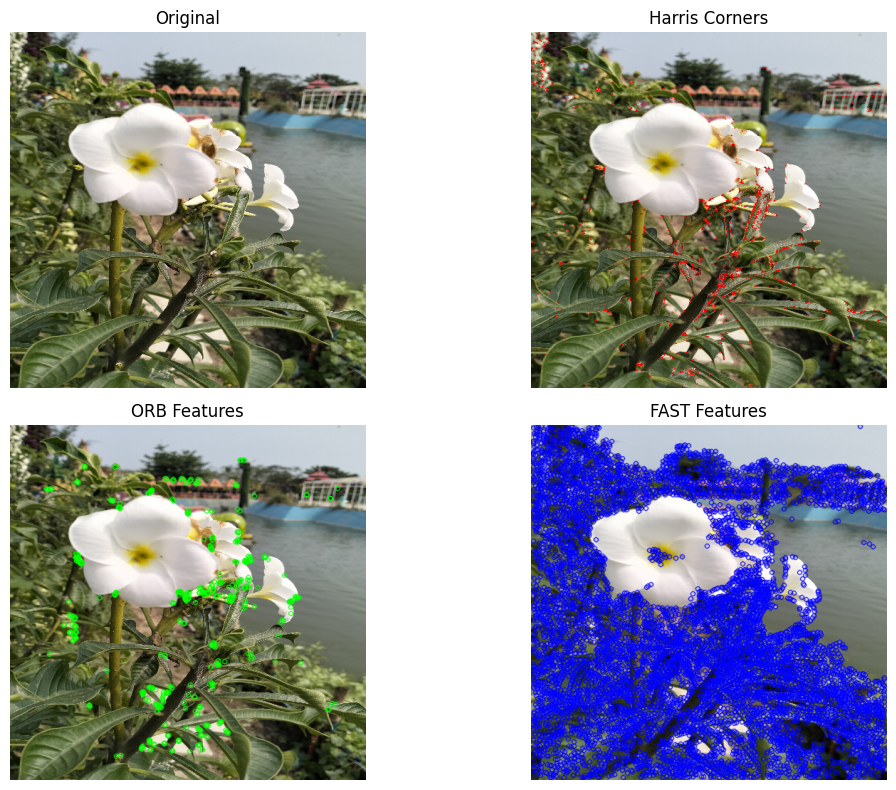

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- 1. Read Image --------
img = cv2.imread("/content/drive/MyDrive/dataset/img.jpg")
img = cv2.resize(img, (500, 500))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------- 2. Harris Corner Detection --------
gray_float = np.float32(gray)
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)

harris_img = img_rgb.copy()
harris_img[harris > 0.01 * harris.max()] = [255, 0, 0]  # mark corners

# -------- 3. ORB Feature Detection --------
orb = cv2.ORB_create()
kp_orb = orb.detect(gray, None)
orb_img = cv2.drawKeypoints(img_rgb, kp_orb, None, color=(0,255,0))

# -------- 4. FAST Feature Detection --------
fast = cv2.FastFeatureDetector_create()
kp_fast = fast.detect(gray, None)
fast_img = cv2.drawKeypoints(img_rgb, kp_fast, None, color=(0,0,255))

# -------- 5. Display --------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Harris Corners")
plt.imshow(harris_img)
plt.axis('off')

plt.subplot(2,2,3)
plt.title("ORB Features")
plt.imshow(orb_img)
plt.axis('off')

plt.subplot(2,2,4)
plt.title("FAST Features")
plt.imshow(fast_img)
plt.axis('off')

plt.tight_layout()
plt.show()